The goal of this task is to predict the continuous median house value (MedHouseVal) for various districts in California.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

california = fetch_california_housing(as_frame=True)
df_cal = california.frame

# Display the size of the dataset and the first few rows
print(f"Data Shape (Rows, Columns): {df_cal.shape}\n")
display(df_cal.head())

Data Shape (Rows, Columns): (20640, 9)



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Data Cleaning & Preprocessing

In [2]:
# Check for missing values in every column
missing_values = df_cal.isnull().sum()
print("Missing Values per Column:\n", missing_values)

Missing Values per Column:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


Exploratory Data Analysis (EDA) & Visualizations

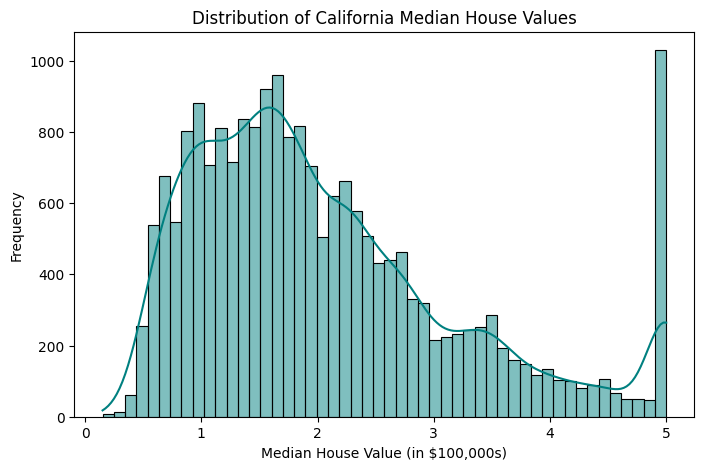

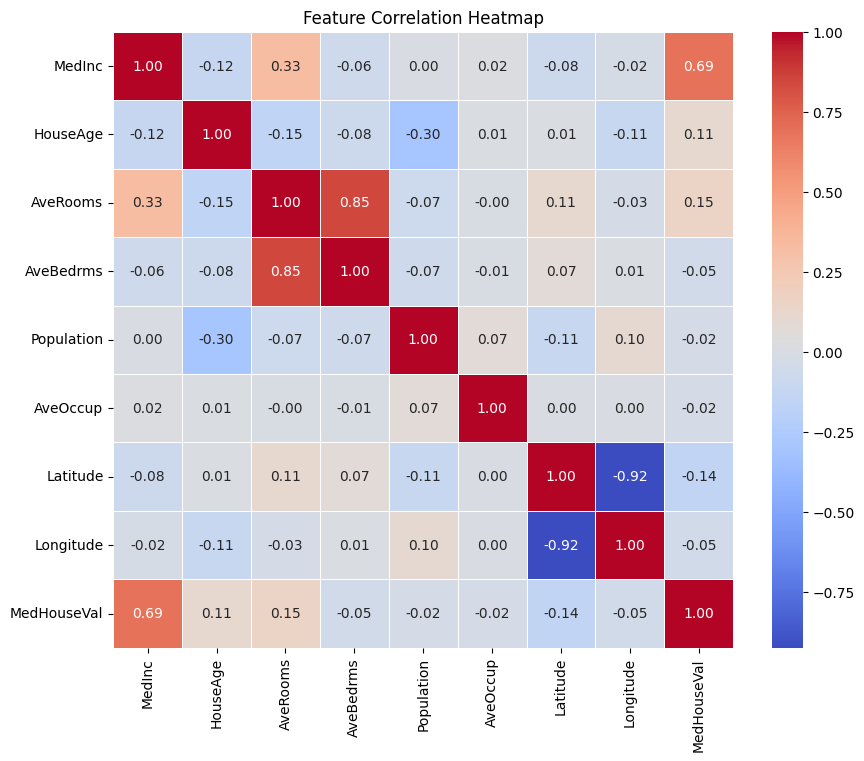

In [3]:
# 1. Histogram of the Target Variable
plt.figure(figsize=(8, 5))
sns.histplot(df_cal['MedHouseVal'], bins=50, kde=True, color='teal')
plt.title('Distribution of California Median House Values')
plt.xlabel('Median House Value (in $100,000s)')
plt.ylabel('Frequency')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
# We calculate the correlation matrix and visualize it
correlation_matrix = df_cal.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

Key Insights from EDA
* zero missing values in this dataset, so no imputation (filling in blanks) is required.
* The median house values are mostly concentrated between 1.0 and 3.0 However, there is a weird, artificial spike right at 5.0 ($500k).

* Looking at the heatmap, MedInc (Median Income) has the strongest positive correlation (0.69) with MedHouseVal. This makes logical sense: areas where people earn more money tend to have more expensive homes.

Model Training & Evaluation
* We will use an 80/20 train-test split.

I will evaluate it using:
* RMSE (Root Mean Squared Error): The average error in the predicted house prices.
* R-squared ($R^2$): How much of the variance in house prices the model successfully explains.

In [4]:
# 1. Separate features (X) from the target (y)
X = df_cal.drop('MedHouseVal', axis=1)
y = df_cal['MedHouseVal']

# 2. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make predictions on the test set
predictions = model.predict(X_test)

# 5. Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("--- Linear Regression Results ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} ")
print(f"R-squared (R2) Score: {r2:.4f}")

--- Linear Regression Results ---
Root Mean Squared Error (RMSE): 0.7456 
R-squared (R2) Score: 0.5758


Root Mean Squared Error: 0.80 (Average prediction error magnitude)


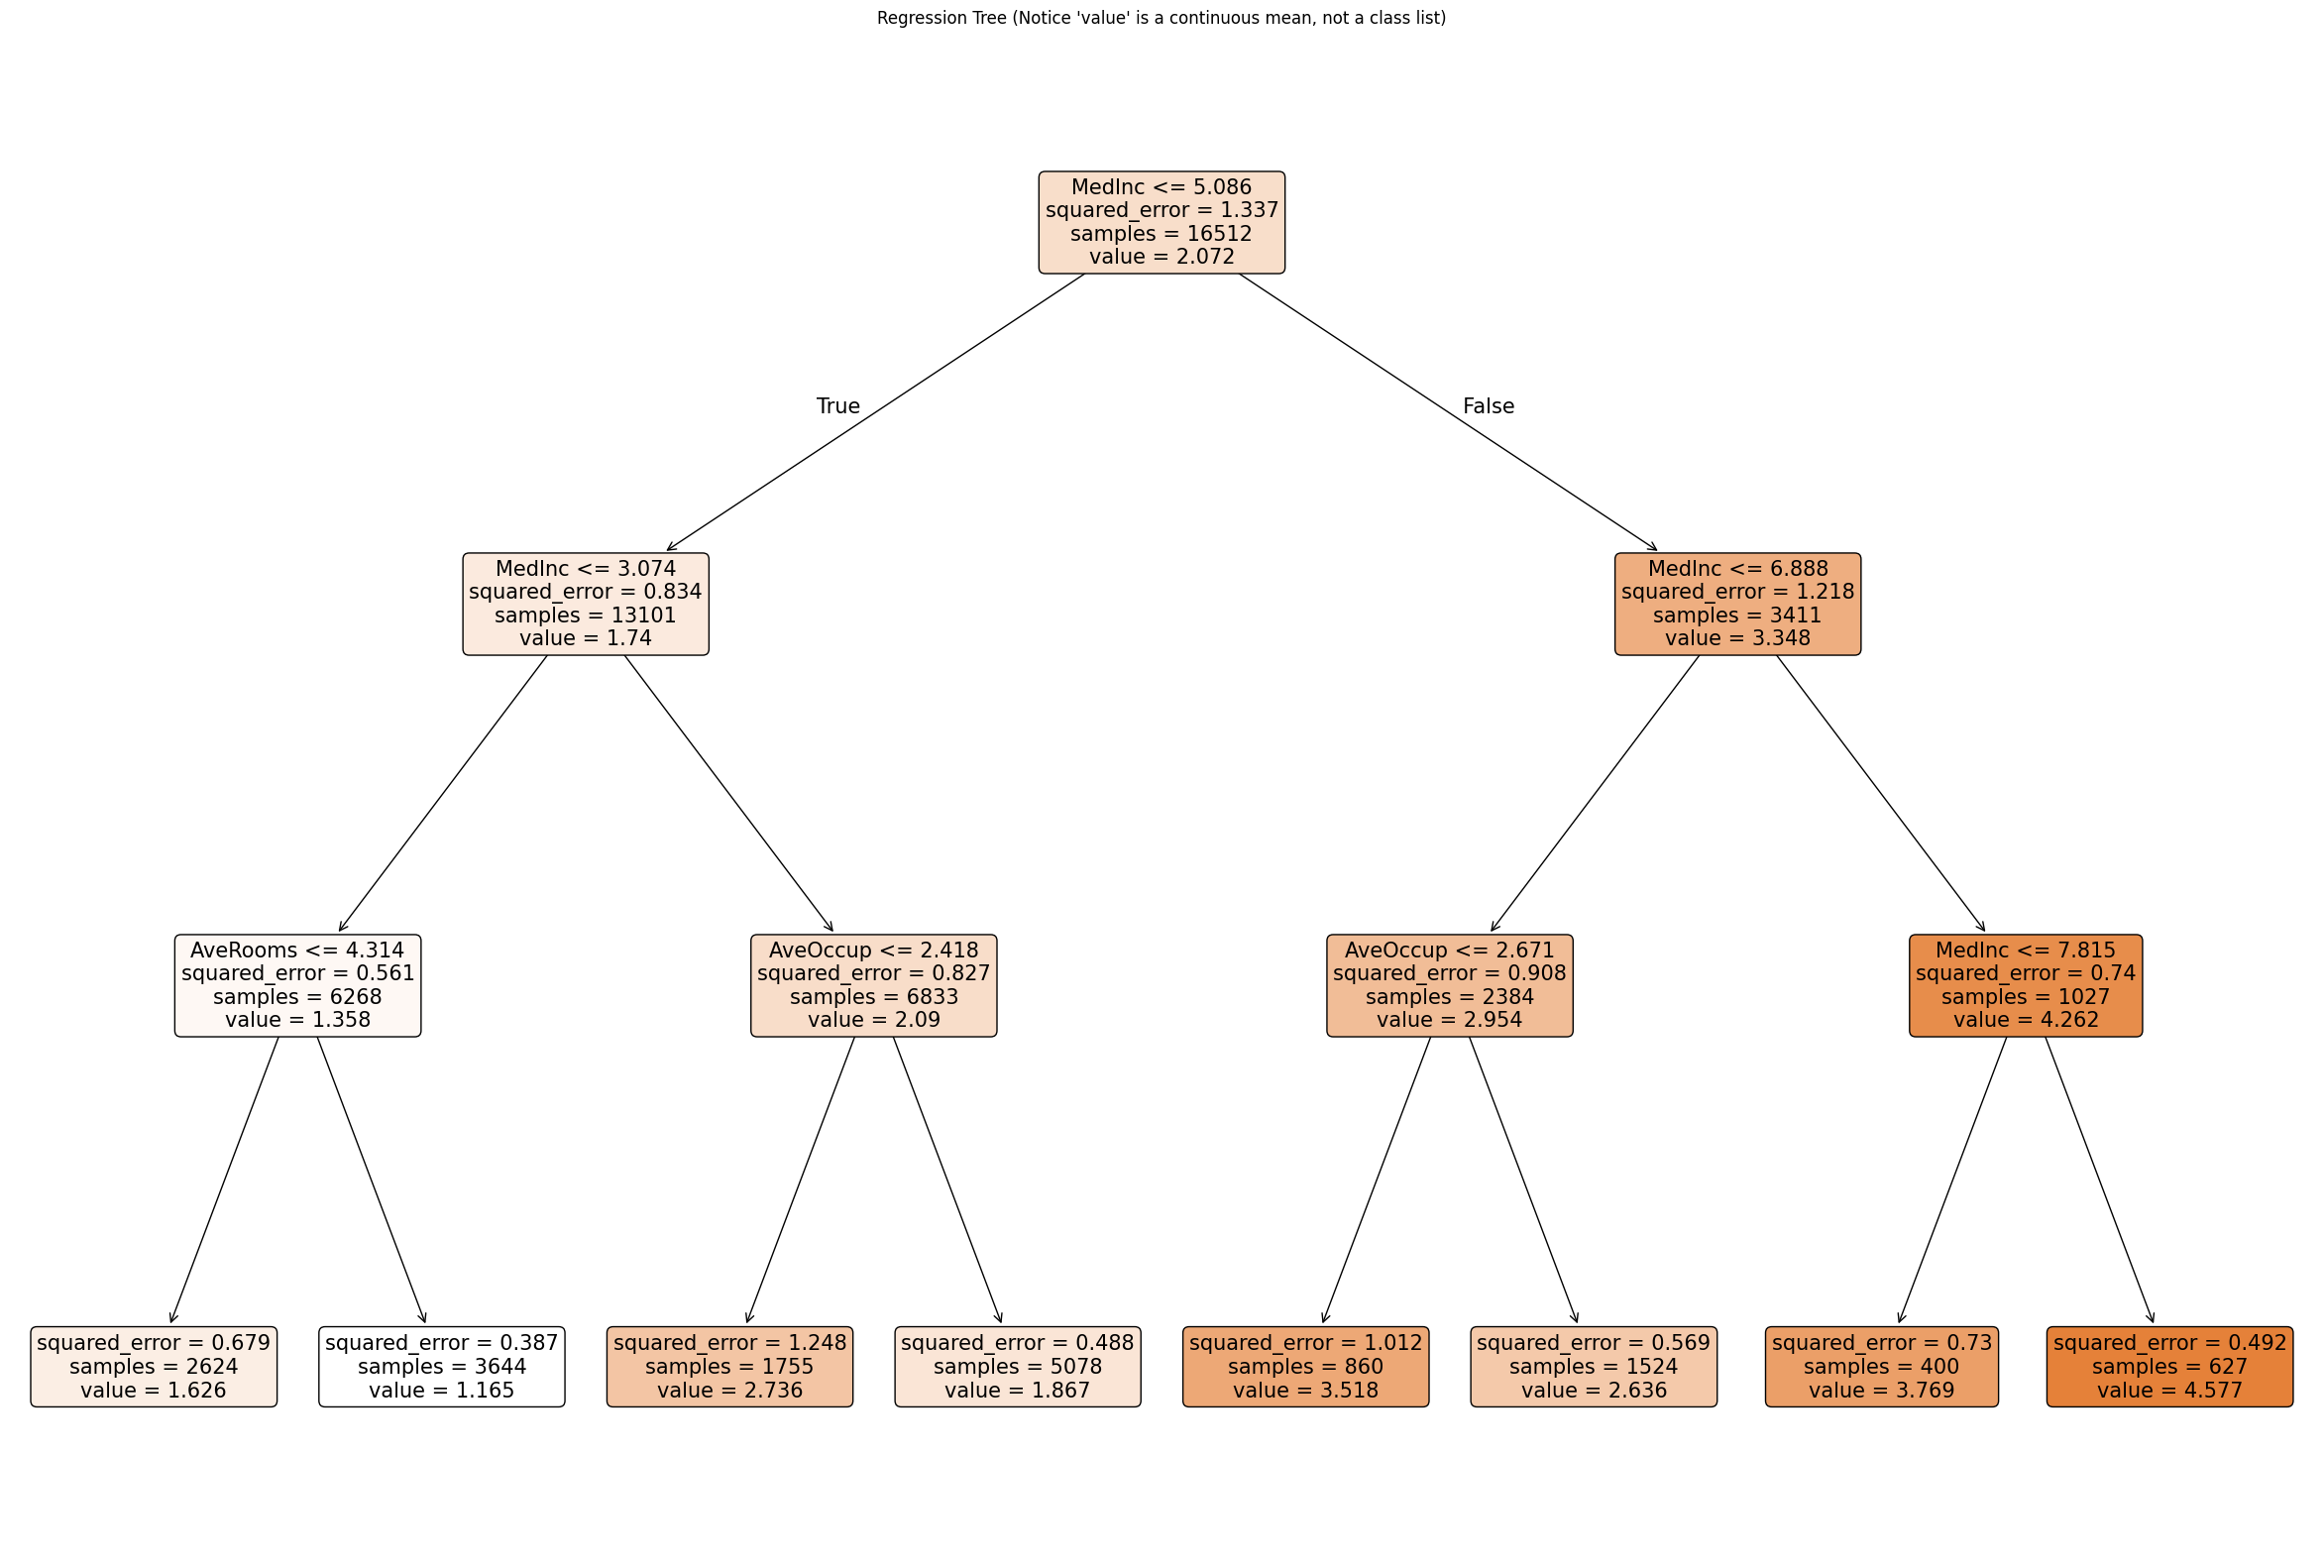

In [9]:
from sklearn.tree import DecisionTreeRegressor,plot_tree



# 1. Model: Notice we use DecisionTreeRegressor!
reg_tree = DecisionTreeRegressor(max_depth=3, random_state=42)

# 2. Train
reg_tree.fit(X_train, y_train)

# 3. Predict
y_pred = reg_tree.predict(X_test)

# 4. Evaluate using RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error: {rmse:.2f} (Average prediction error magnitude)")

# Show tree outputting continuous Values
plt.figure(figsize=(30, 20))
plot_tree(reg_tree, feature_names=X_train.columns, filled=True, rounded=True, fontsize=15)
plt.title("Regression Tree (Notice 'value' is a continuous mean, not a class list)")
plt.show()

Hyperparameter Tuning

In [11]:
from sklearn.model_selection import GridSearchCV

# 1. Define the Grid of parameters to test
# We'll test depth from 2 to 10, and different min_samples thresholds.
param_grid = {
    'max_depth': [2, 3, 4, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

# 2. Initialize a base model
base_tree = DecisionTreeRegressor(random_state=42)

# 3. Set up GridSearchCV
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(estimator=base_tree, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# 4. Fit the GridSearch to the training data (This will run many models!)
print("Starting Grid Search (testing combinations)...")
grid_search.fit(X_train, y_train)

# 5. See the results!
print("\n--- Grid Search Results ---")
print(f"Best Accuracy Score (CV): {grid_search.best_score_:.3f}")
print("Best Hyperparameters Found:")
print(grid_search.best_params_)

# 6. Use the best model on our hidden Test Set
best_model = grid_search.best_estimator_
final_test_accuracy = best_model.score(X_test, y_test)
print(f"\nFinal Test Accuracy with tuned model: {final_test_accuracy:.3f}")

Starting Grid Search (testing combinations)...

--- Grid Search Results ---
Best Accuracy Score (CV): -0.378
Best Hyperparameters Found:
{'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}

Final Test Accuracy with tuned model: 0.711


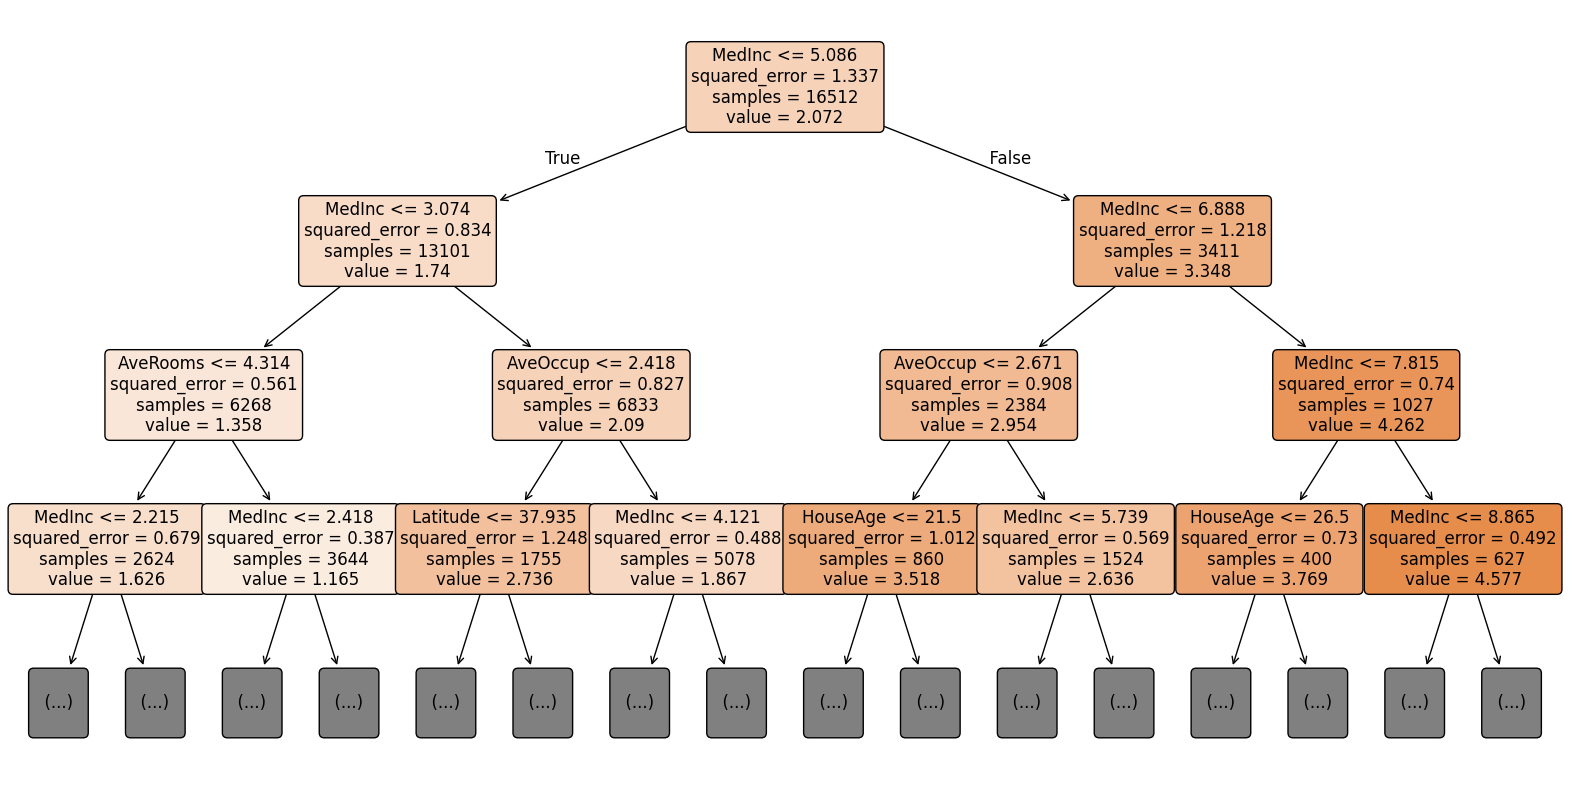

In [ ]:

plt.figure(figsize=(20, 10))    
plot_tree(best_model, 
          max_depth=3, # This only limits the PICTURE, not the actual model
          feature_names=X_train.columns, 
          filled=True, rounded=True, fontsize=12)
plt.show()